<a href="https://colab.research.google.com/github/iqlore-collab/UNSUPERVISED-MASHINE-LEARNING/blob/main/spotify_playlist_clustering_github_clean_upgraded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Playlist Clustering

I build a compact K-Means prototype for grouping songs into playlist-like clusters using Spotify audio features.

## 1. Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin_min
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
FILE_ID = "1a-JNdTUduvxHU45uS0u_DQ6wirsSZDXG"
DATA_URL = f"https://drive.google.com/uc?id={FILE_ID}"

## 2. Load and prepare data

I keep identifiers for interpretation and use only numeric audio features for clustering.

This version also removes index-like columns such as `Unnamed: 0` and creates two feature sets:

- with `duration_ms`,
- without `duration_ms`.

The final clustering prototype uses the version without `duration_ms`, because song duration can dominate distance-based clustering even though it is not always a meaningful playlist identity signal.


In [2]:
def load_spotify_data(url: str = DATA_URL) -> pd.DataFrame:
    df = pd.read_csv(url)
    df.columns = df.columns.str.strip()
    return df


METADATA_COLS = (
    "Unnamed: 0",
    "name",
    "artist",
    "id",
    "html",
    "type",
    "uri",
    "track_id",
    "album",
    "album_name",
    "release_date",
)


def get_feature_frame(
    df: pd.DataFrame,
    metadata_cols=METADATA_COLS,
    drop_duration: bool = False,
) -> pd.DataFrame:
    numeric = df.drop(columns=list(metadata_cols), errors="ignore")
    numeric = numeric.select_dtypes(include="number")
    numeric = numeric.drop(columns=["Unnamed: 0"], errors="ignore")
    numeric = numeric.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")
    numeric = numeric.fillna(numeric.median(numeric_only=True))

    if drop_duration:
        numeric = numeric.drop(columns=["duration_ms"], errors="ignore")

    return numeric


songs_df = load_spotify_data()

songs_features_with_duration = get_feature_frame(songs_df, drop_duration=False)
songs_features = get_feature_frame(songs_df, drop_duration=True)

print(f"Rows: {songs_df.shape[0]:,}")
print(f"Audio features with duration_ms: {songs_features_with_duration.shape[1]}")
print(f"Final audio features without duration_ms: {songs_features.shape[1]}")

print("\nFinal feature columns:")
print(songs_features.columns.tolist())

display(songs_df.head())
display(songs_features.describe().T.round(3))


Rows: 5,235
Audio features with duration_ms: 13
Final audio features without duration_ms: 12

Final feature columns:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


,count,mean,std,min,25%,50%,75%,max
danceability,5235.0,0.510,0.218,0.0,0.309,0.539,0.688,0.967
energy,5235.0,0.654,0.288,0.0,0.479,0.738,0.893,1.000
key,5235.0,5.254,3.572,0.0,2.000,5.000,8.000,11.000
loudness,5235.0,-9.338,6.295,-60.0,-11.337,-7.338,-5.264,1.342
mode,5235.0,0.646,0.478,0.0,0.000,1.000,1.000,1.000
speechiness,5235.0,0.083,0.071,0.0,0.039,0.056,0.099,0.918
acousticness,5235.0,0.290,0.356,0.0,0.002,0.095,0.565,0.996
instrumentalness,5235.0,0.257,0.371,0.0,0.000,0.002,0.643,0.985
liveness,5235.0,0.185,0.149,0.0,0.092,0.125,0.237,0.987
valence,5235.0,0.444,0.278,0.0,0.196,0.417,0.677,0.985


### Feature selection check

The following cell verifies that index-like and non-audio columns are not used in clustering.


In [3]:
excluded_candidates = ["Unnamed: 0", "name", "artist", "id", "html", "type", "duration_ms"]

feature_check = pd.DataFrame({
    "column": excluded_candidates,
    "in_final_features": [col in songs_features.columns for col in excluded_candidates],
    "in_raw_data": [col in songs_df.columns for col in excluded_candidates],
})

feature_check


,column,in_final_features,in_raw_data
0,Unnamed: 0,False,True
1,name,False,True
2,artist,False,True
3,id,False,True
4,html,False,True
5,type,False,True
6,duration_ms,False,True


## 3. Scaling comparison

I compare several scaling options and keep StandardScaler for the final prototype because K-Means depends on distances.

In [4]:
SCALERS = {
    "raw": None,
    "minmax": MinMaxScaler(),
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "quantile": QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE),
    "power": PowerTransformer(),
}


def scale_features(X: pd.DataFrame, scaler) -> pd.DataFrame:
    if scaler is None:
        return X.copy()
    scaled = scaler.fit_transform(X)
    return pd.DataFrame(scaled, columns=X.columns, index=X.index)


scaled_frames = {name: scale_features(songs_features, scaler) for name, scaler in SCALERS.items()}

feature = "tempo" if "tempo" in songs_features.columns else songs_features.columns[0]
comparison = pd.concat(
    [frame[feature].rename(name) for name, frame in scaled_frames.items()],
    axis=1,
)
display(comparison.head())

,raw,minmax,standard,robust,quantile,power
0,110.376,0.515800,-0.292147,-0.232633,-0.229019,-0.235735
1,125.039,0.584322,0.221160,0.154816,0.236460,0.279924
2,93.698,0.437862,-0.875994,-0.673325,-0.854371,-0.866925
3,106.802,0.499098,-0.417262,-0.327071,-0.328253,-0.366653
4,120.941,0.565171,0.077701,0.046532,0.075569,0.139074


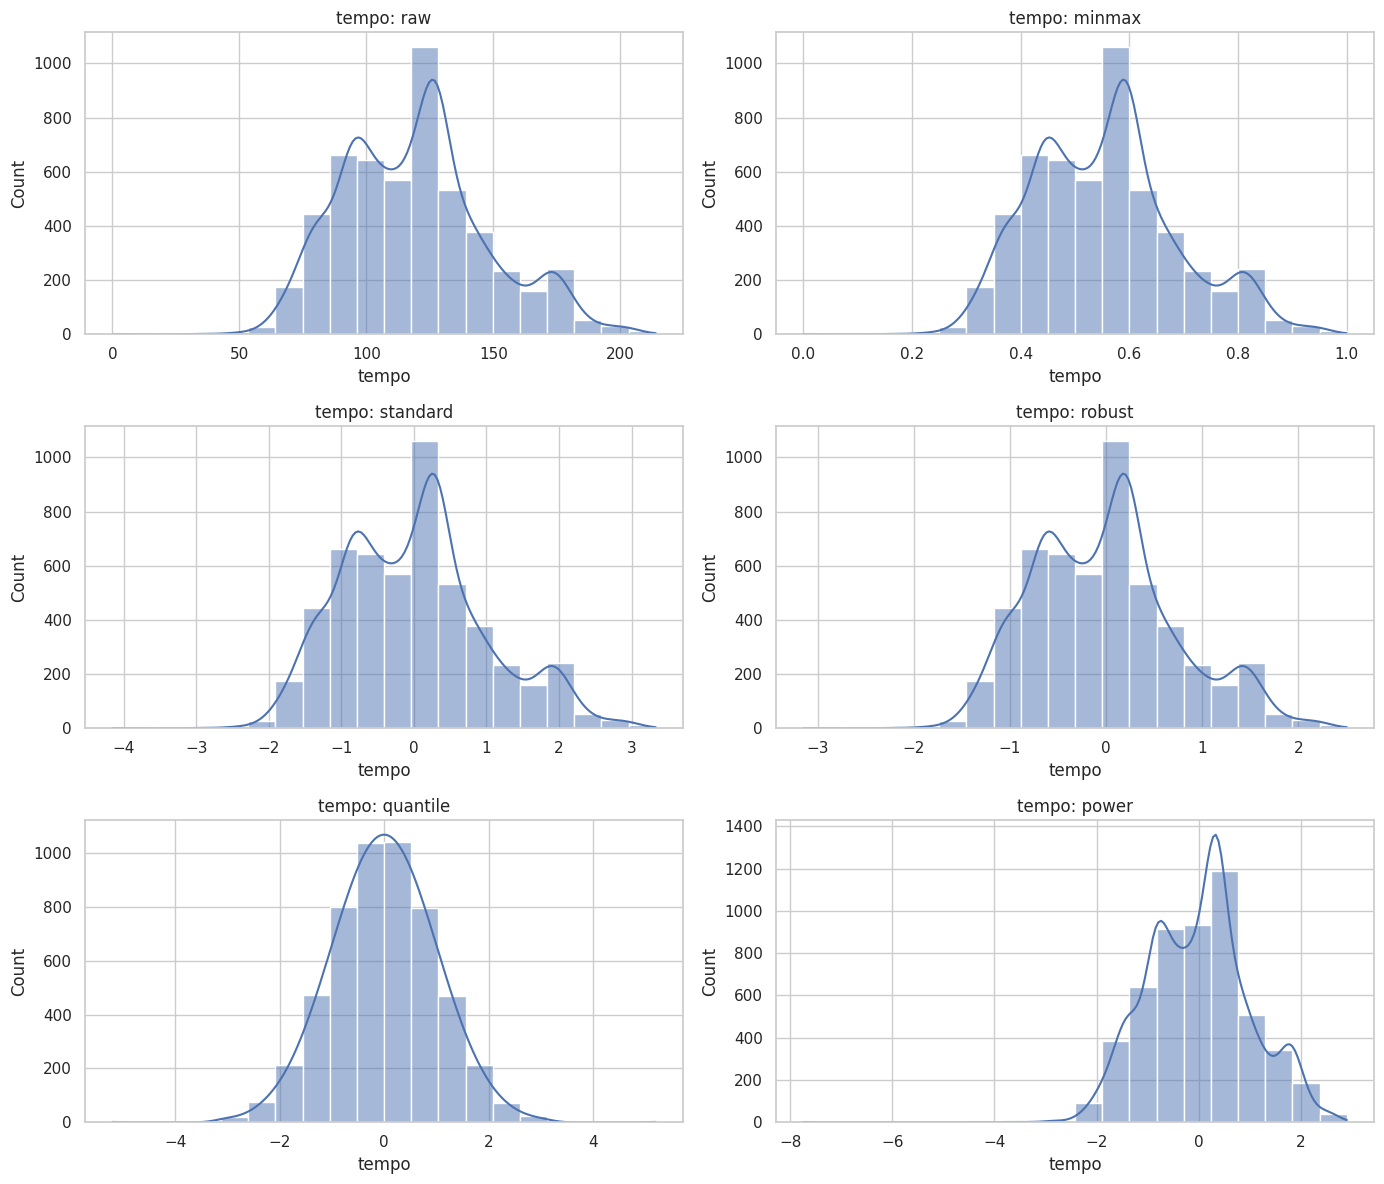

In [5]:
def plot_scaler_histograms(frames: dict[str, pd.DataFrame], feature: str, bins: int = 20) -> None:
    rows = int(np.ceil(len(frames) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).ravel()

    for ax, (name, frame) in zip(axes, frames.items()):
        sns.histplot(frame[feature], bins=bins, kde=True, ax=ax)
        ax.set_title(f"{feature}: {name}")

    for ax in axes[len(frames):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_scaler_histograms(scaled_frames, feature)

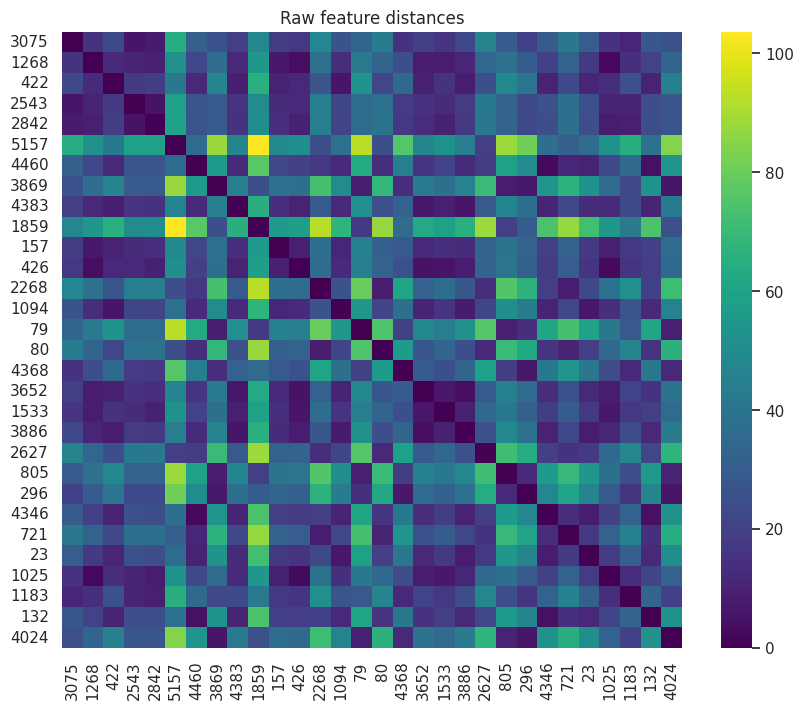

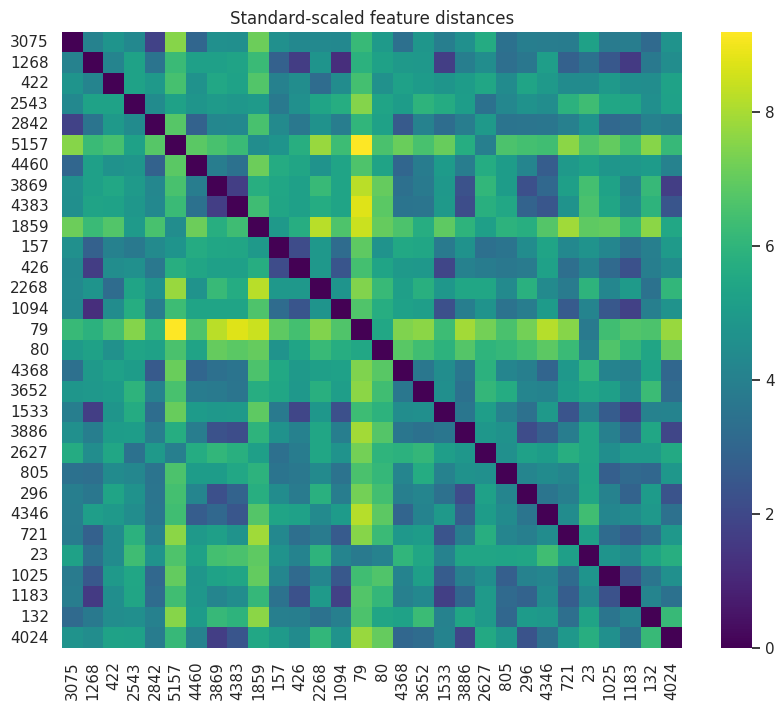

In [6]:
def plot_distance_heatmap(X: pd.DataFrame, title: str, sample_size: int = 30) -> None:
    sample = X.sample(min(sample_size, len(X)), random_state=RANDOM_STATE)
    distances = pd.DataFrame(
        pairwise_distances(sample),
        index=sample.index,
        columns=sample.index,
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(distances, cmap="viridis")
    plt.title(title)
    plt.show()


plot_distance_heatmap(songs_features, "Raw feature distances")
plot_distance_heatmap(scaled_frames["standard"], "Standard-scaled feature distances")

## 4. Estimate cluster count

I compare statistical metrics with the business requirement. The metric-based choice is useful for model quality, while `k=50` is useful for a playlist catalog that feels broad enough for the product.

In [7]:
X = scaled_frames["standard"]


def evaluate_kmeans(X: pd.DataFrame, k_range=range(2, 51)) -> pd.DataFrame:
    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)
        rows.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
        })
    return pd.DataFrame(rows)


k_scores = evaluate_kmeans(X)
display(k_scores.sort_values("silhouette", ascending=False).head(10))

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,49905.458717,0.280682,1354.196440,1.487794
1,3,42817.638875,0.202307,1222.070578,1.752531
4,6,34922.095965,0.177829,835.448940,1.636166
3,5,36972.820838,0.174099,914.054865,1.751988
2,4,39556.660202,0.171359,1025.454568,1.896628
6,8,31088.237769,0.170050,762.171222,1.553296
5,7,33140.122615,0.160167,780.355184,1.662772
7,9,29912.388599,0.150869,718.662004,1.599886
8,10,29066.410310,0.147144,674.174547,1.760722
9,11,28014.269350,0.145982,649.045521,1.708280


### Duration sensitivity check

`duration_ms` can dominate clustering because it is measured on a much larger scale before scaling and may still create strong separation after scaling.

The next cell compares clustering quality with and without `duration_ms`.  
The final prototype continues with the no-duration version to focus clusters on audio mood and style.


,k,silhouette_without_duration,silhouette_with_duration,davies_bouldin_without_duration,davies_bouldin_with_duration
0,2,0.280682,0.289779,1.487794,1.559083
1,3,0.202307,0.191134,1.752531,1.796739
2,4,0.171359,0.156958,1.896628,1.949007
3,5,0.174099,0.159152,1.751988,1.800963
4,6,0.177829,0.166012,1.636166,1.660331


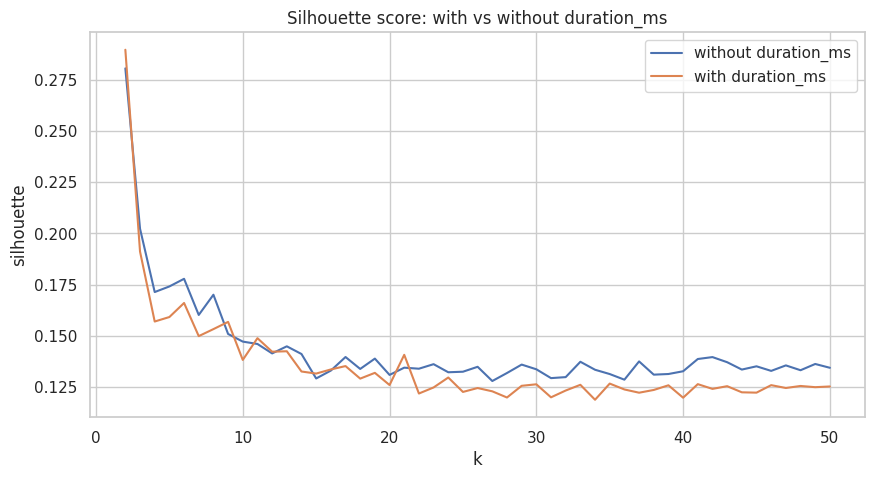

In [8]:
X_with_duration = scale_features(songs_features_with_duration, StandardScaler())

k_scores_with_duration = evaluate_kmeans(X_with_duration)

duration_comparison = pd.DataFrame({
    "k": k_scores["k"],
    "silhouette_without_duration": k_scores["silhouette"],
    "silhouette_with_duration": k_scores_with_duration["silhouette"],
    "davies_bouldin_without_duration": k_scores["davies_bouldin"],
    "davies_bouldin_with_duration": k_scores_with_duration["davies_bouldin"],
})

display(duration_comparison.head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=duration_comparison, x="k", y="silhouette_without_duration", label="without duration_ms")
sns.lineplot(data=duration_comparison, x="k", y="silhouette_with_duration", label="with duration_ms")
plt.title("Silhouette score: with vs without duration_ms")
plt.ylabel("silhouette")
plt.show()


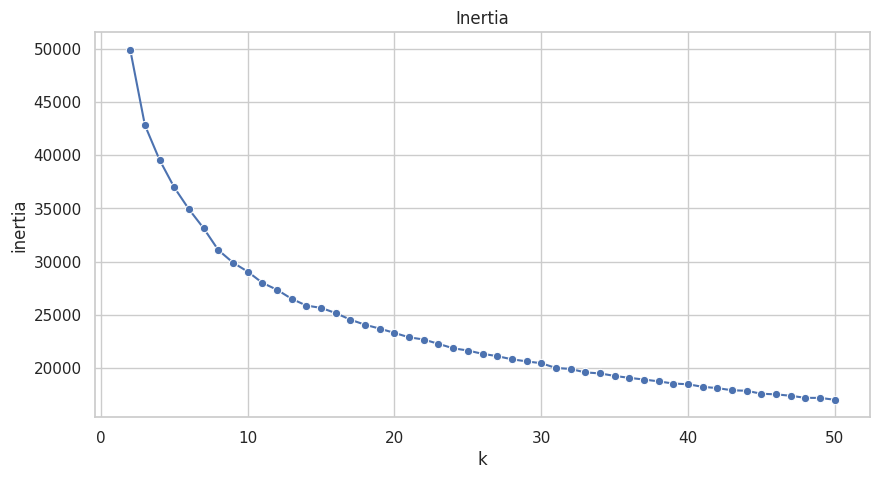

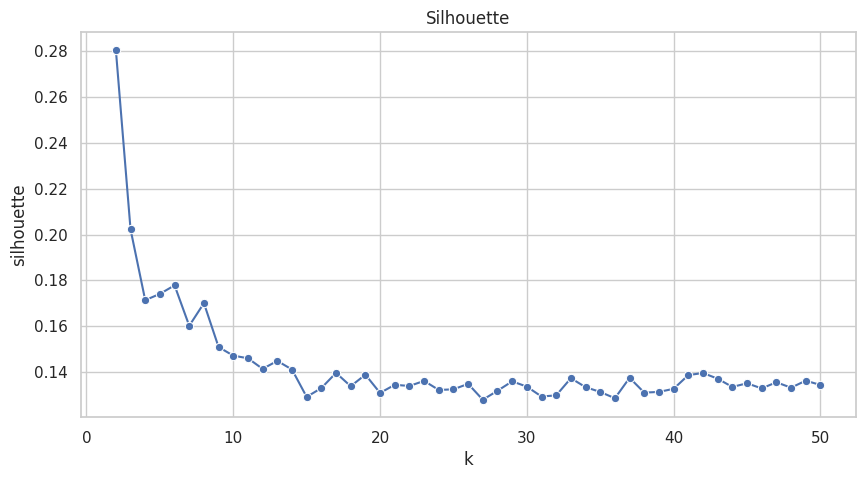

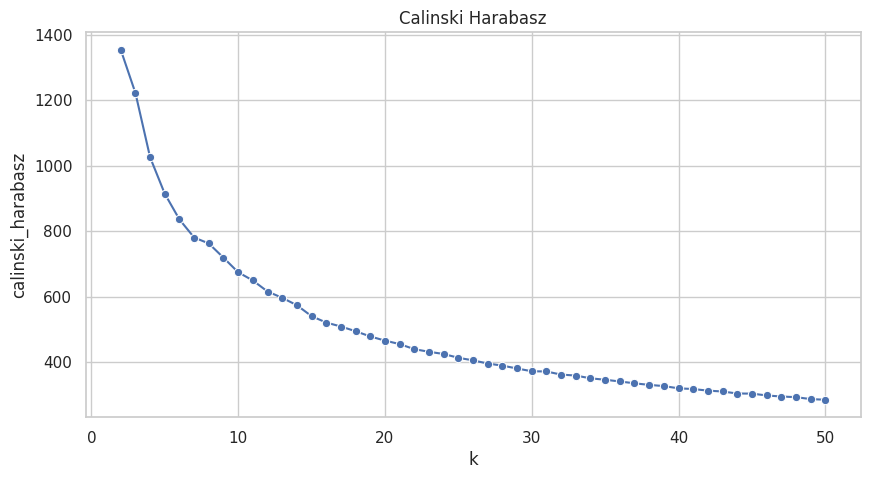

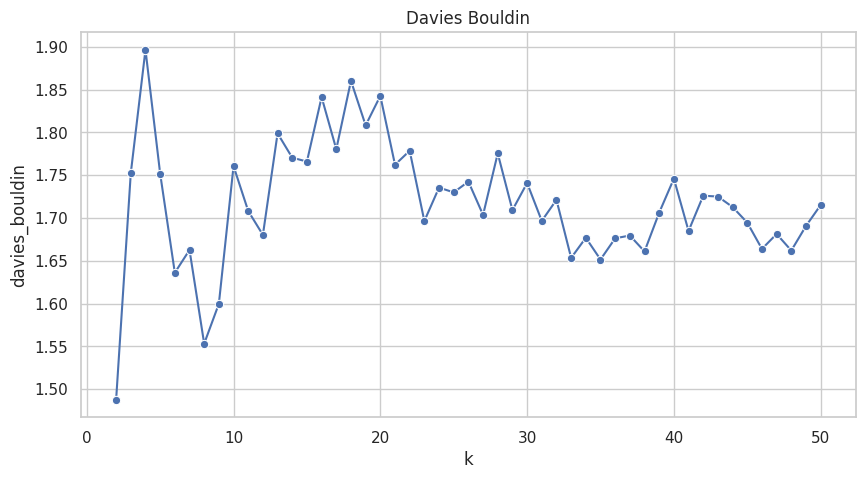

In [9]:
def plot_metric(df: pd.DataFrame, metric: str, ylabel: str | None = None) -> None:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x="k", y=metric, marker="o")
    plt.title(metric.replace("_", " ").title())
    plt.ylabel(ylabel or metric)
    plt.show()


for metric in ["inertia", "silhouette", "calinski_harabasz", "davies_bouldin"]:
    plot_metric(k_scores, metric)

In [10]:
def choose_k(scores: pd.DataFrame, method: str = "silhouette") -> int:
    if method == "silhouette":
        return int(scores.loc[scores["silhouette"].idxmax(), "k"])
    if method == "calinski_harabasz":
        return int(scores.loc[scores["calinski_harabasz"].idxmax(), "k"])
    if method == "davies_bouldin":
        return int(scores.loc[scores["davies_bouldin"].idxmin(), "k"])
    raise ValueError("method must be: silhouette, calinski_harabasz, or davies_bouldin")


METRIC_K = choose_k(k_scores, method="silhouette")
BUSINESS_K = 50

print(f"Metric-selected clusters: {METRIC_K}")
print(f"Business-selected clusters: {BUSINESS_K}")

display(
    k_scores[k_scores["k"].isin([METRIC_K, BUSINESS_K])]
    .sort_values("k")
    .reset_index(drop=True)
)


Metric-selected clusters: 2
Business-selected clusters: 50


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,49905.458717,0.280682,1354.196440,1.487794
1,50,17028.219204,0.134343,284.558119,1.715285


## 5. Build playlist clusters

I use `k=50` for the business-facing prototype. This creates a richer playlist catalog than the metric-selected version and gives Moosic more playlist variety to evaluate.

In [11]:
def cluster_songs(X: pd.DataFrame, k: int) -> tuple[KMeans, pd.Series]:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = pd.Series(model.fit_predict(X), index=X.index, name="cluster")
    return model, labels


kmeans_model, cluster_labels = cluster_songs(X, BUSINESS_K)

songs_clusters_df = songs_df.copy()
songs_clusters_df["cluster"] = cluster_labels.values

cluster_sizes = (
    songs_clusters_df["cluster"]
    .value_counts()
    .sort_values()
    .rename_axis("cluster")
    .reset_index(name="songs")
)

display(cluster_sizes)


,cluster,songs
0,7,25
1,23,28
2,28,35
3,45,36
4,39,42
5,34,43
6,29,48
7,24,56
8,44,62
9,46,63


### PCA visualization

K-Means is trained in the full feature space.  
PCA helps us project the clusters into two dimensions for visual inspection.


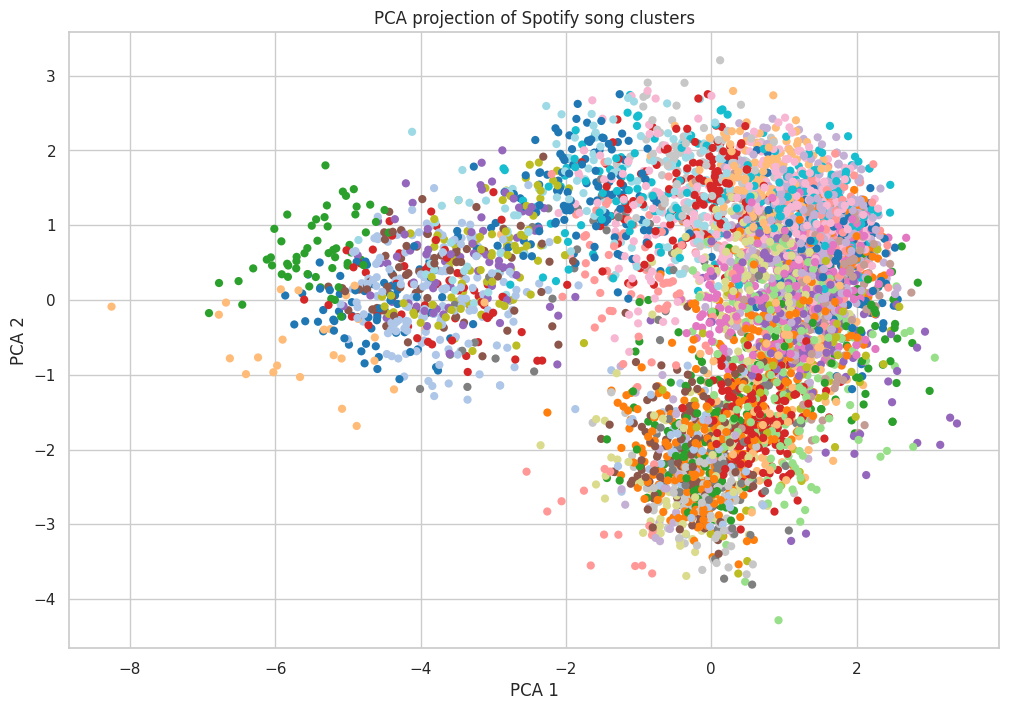

Explained variance ratio: [0.275 0.157]


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    "cluster": cluster_labels,
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab20",
    s=35,
    linewidth=0,
    legend=False,
)

plt.title("PCA projection of Spotify song clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))


## 6. Business analysis for 50 clusters

I inspect cluster size distribution to check whether 50 playlists are usable. Very small clusters can be valuable niche playlists, but they may also indicate that the model is over-segmenting the catalog.

,songs
count,50.00
mean,104.70
std,51.45
min,25.00
10%,42.90
25%,68.00
50%,92.00
75%,130.25
90%,174.60
max,260.00


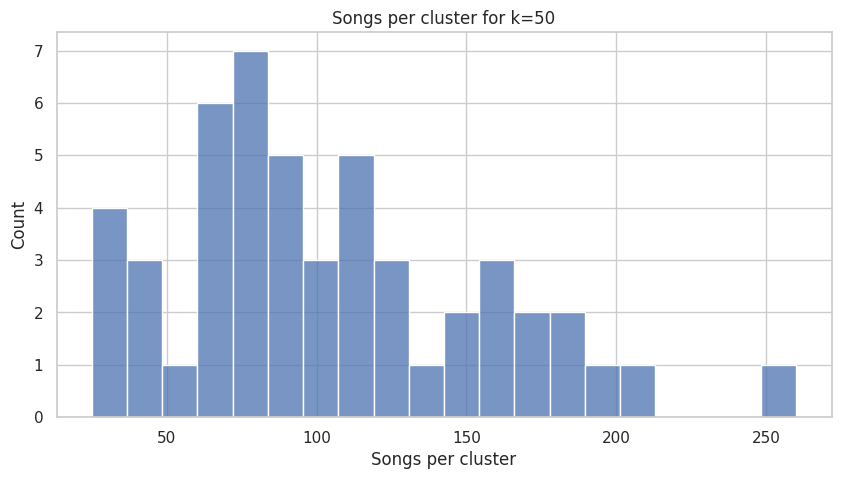

In [13]:
def summarize_cluster_sizes(cluster_sizes: pd.DataFrame) -> pd.DataFrame:
    size_stats = cluster_sizes["songs"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    return size_stats.to_frame("songs").round(2)


display(summarize_cluster_sizes(cluster_sizes))

plt.figure(figsize=(10, 5))
sns.histplot(cluster_sizes["songs"], bins=20)
plt.title("Songs per cluster for k=50")
plt.xlabel("Songs per cluster")
plt.show()


### Small cluster diagnostics

Very small clusters may represent useful niche playlists, but they can also indicate over-segmentation.


In [14]:
small_clusters = cluster_sizes[cluster_sizes["songs"] < 10].sort_values("songs")

print("Clusters with fewer than 10 songs:")
display(small_clusters)


Clusters with fewer than 10 songs:


,cluster,songs


In [15]:
def get_small_cluster(
    cluster_sizes: pd.DataFrame,
    min_size: int = 3,
    max_size: int = 15,
) -> int:
    candidates = cluster_sizes[
        cluster_sizes["songs"].between(min_size, max_size)
    ].sort_values("songs")

    if candidates.empty:
        candidates = cluster_sizes.sort_values("songs")

    return int(candidates.iloc[0]["cluster"])


def list_cluster_songs(
    df: pd.DataFrame,
    cluster: int,
    limit: int = 25,
) -> pd.DataFrame:
    cols = [
        col for col in [
            "name",
            "artist",
            "cluster",
            "danceability",
            "energy",
            "valence",
            "tempo",
        ]
        if col in df.columns
    ]

    return (
        df[df["cluster"] == cluster]
        .sort_values([col for col in ["artist", "name"] if col in df.columns])
        [cols]
        .head(limit)
    )


SMALL_CLUSTER = get_small_cluster(cluster_sizes)

print(f"Small cluster selected for inspection: {SMALL_CLUSTER}")
display(list_cluster_songs(songs_clusters_df, SMALL_CLUSTER))


Small cluster selected for inspection: 7


,name,artist,cluster,danceability,energy,valence,tempo
4359,Jesus Is Dead! ...,Altar,7,0.4200,0.910,0.2670,102.359
4213,Emperors of Salvation ...,Asphyx,7,0.2250,0.961,0.0659,135.600
4931,Unendlichkeit ...,CRO,7,0.3120,0.672,0.4250,77.658
3590,Amidst the Ruins ...,Deeds of Flesh,7,0.3020,0.990,0.0532,115.726
4149,In Torment in Hell ...,Deicide,7,0.3350,0.976,0.2400,93.203
3768,Repent to Die ...,Deicide,7,0.3410,0.922,0.5120,135.372
4033,Deadspawn ...,Disincarnate,7,0.1460,0.966,0.1640,171.171
3456,Wolverine Blues ...,Entombed,7,0.3480,0.973,0.3740,152.235
4457,Rites of Red Giving ...,Equinox,7,0.2170,0.891,0.2390,138.254
4373,Blood On White ...,Funebre,7,0.2170,0.740,0.3190,106.917


## 7. Cluster profiles

I summarize each playlist by average audio feature values and representative songs near each centroid.

In [16]:
def build_cluster_profiles(df: pd.DataFrame, features: pd.DataFrame, label_col: str = "cluster") -> pd.DataFrame:
    profile = df.join(features.add_suffix("_raw"))
    audio_cols = [f"{col}_raw" for col in features.columns]
    summary = profile.groupby(label_col)[audio_cols].mean().round(3)
    summary["cluster_size"] = df.groupby(label_col).size()
    return summary.sort_values("cluster_size", ascending=False)


cluster_profiles = build_cluster_profiles(songs_clusters_df, songs_features)
display(cluster_profiles)

,danceability_raw,energy_raw,key_raw,loudness_raw,mode_raw,speechiness_raw,acousticness_raw,instrumentalness_raw,liveness_raw,valence_raw,tempo_raw,time_signature_raw,cluster_size
cluster,,,,,,,,,,,,,
13,0.726,0.733,7.815,-6.585,1.000,0.061,0.137,0.026,0.116,0.777,114.927,4.004,260
22,0.265,0.903,7.995,-8.370,1.000,0.103,0.007,0.773,0.181,0.220,110.534,4.039,203
49,0.753,0.751,3.183,-5.879,0.000,0.070,0.150,0.024,0.131,0.757,109.362,3.995,191
48,0.623,0.785,9.164,-5.275,0.000,0.055,0.069,0.058,0.173,0.397,123.480,4.000,183
27,0.691,0.828,1.211,-5.165,1.000,0.059,0.091,0.057,0.170,0.765,120.997,4.000,180
32,0.573,0.753,8.213,-5.908,1.000,0.052,0.081,0.054,0.127,0.347,115.892,4.000,174
17,0.634,0.716,1.382,-6.030,1.000,0.054,0.113,0.073,0.127,0.351,115.088,4.000,173
10,0.268,0.902,1.506,-8.457,1.000,0.101,0.009,0.784,0.198,0.238,105.589,4.012,164
38,0.763,0.708,9.457,-6.511,0.000,0.070,0.166,0.057,0.132,0.758,108.872,4.006,164


In [17]:
def get_representative_songs(
    df: pd.DataFrame,
    X: pd.DataFrame,
    model: KMeans,
    labels: pd.Series,
    songs_per_cluster: int = 5,
) -> pd.DataFrame:
    nearest_idx, distances = pairwise_distances_argmin_min(model.cluster_centers_, X)
    representatives = []

    for cluster_id, center_idx in enumerate(nearest_idx):
        cluster_members = X[labels == cluster_id]
        center = model.cluster_centers_[cluster_id].reshape(1, -1)
        member_distances = pairwise_distances(cluster_members, center).ravel()
        closest_indices = cluster_members.iloc[np.argsort(member_distances)[:songs_per_cluster]].index

        cols = [col for col in ["name", "artist"] if col in df.columns]
        sample = df.loc[closest_indices, cols].copy()
        sample["cluster"] = cluster_id
        sample["distance_to_centroid"] = np.sort(member_distances)[:songs_per_cluster].round(3)
        representatives.append(sample)

    return pd.concat(representatives).reset_index(drop=True)


representative_songs = get_representative_songs(songs_clusters_df, X, kmeans_model, cluster_labels)
display(representative_songs)

,name,artist,cluster,distance_to_centroid
0,Soy Igual Que Tú (feat. Toby Love) ...,Alexis y Fido,0,0.960
1,Disco Inferno ...,50 Cent,0,1.099
2,Weck mich auf ...,Samy Deluxe,0,1.167
3,Die Eine 2005 ...,Die Firma,0,1.245
4,Where Is The Love? ...,Black Eyed Peas,0,1.263
...,...,...,...,...
245,Ritual ...,Tiësto,49,0.697
246,Jump Around ...,House Of Pain,49,0.760
247,Stadt ...,Cassandra Steen,49,0.762
248,Attention ...,Charlie Puth,49,0.792


## 8. Search and inspect playlists

I use helper functions to inspect clusters without repeating filtering code.

In [18]:
def search_songs(
    df: pd.DataFrame,
    title: str | None = None,
    artist: str | None = None,
    cluster: int | None = None,
    limit: int = 20,
) -> pd.DataFrame:
    result = df.copy()

    if title and "name" in result.columns:
        for word in title.lower().split():
            result = result[result["name"].str.lower().str.contains(word, na=False)]

    if artist and "artist" in result.columns:
        for word in artist.lower().split():
            result = result[result["artist"].str.lower().str.contains(word, na=False)]

    if cluster is not None:
        result = result[result["cluster"] == cluster]

    cols = [col for col in ["name", "artist", "cluster"] if col in result.columns]
    return result[cols].head(limit)


def show_playlist(df: pd.DataFrame, cluster: int, limit: int = 20) -> pd.DataFrame:
    return search_songs(df, cluster=cluster, limit=limit)


display(search_songs(songs_clusters_df, title="love"))
display(show_playlist(songs_clusters_df, cluster=0))

,name,artist,cluster
195,This Is Not A Love Song ...,Nouvelle Vague,19
257,Limit To Your Love ...,James Blake,18
322,Mk Love Triangle ...,Kim,10
337,Falling Out Of Love (With You) ...,The 6ths,9
338,Love Minus Zero ...,Bob Dylan,15
380,Love Will Tear Us Apart ...,Joy Division,27
400,True Love Will Find You In The End ...,The Memories,13
432,The Way You'd Love Her ...,Mac DeMarco,15
438,Love is Lighter Than Air ...,The Magnetic Fields,15
511,"Love Is a Hurtin' Thing - 12"" Version ...",Gloria Ann Taylor,49


,name,artist,cluster
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0
122,Vai (Menina amanhã de manhã) ...,Tom Zé,0
149,Baião Destemperado ...,Barbatuques,0
169,"Canta Canta, Minha Gente ...",Martinho Da Vila,0
172,Alma Não Tem Cor ...,Perotá Chingó,0
204,La Vuelta Al Mundo ...,Calle 13,0
422,Young Blood ...,The Coasters,0
497,Tell Me Something Good ...,Rufus,0
642,Trumpets ...,Jason Derulo,0
662,Mad Love ...,Sean Paul,0


## 9. Prototype assessment

I treat the model as a useful prototype, not as a finished recommendation engine.

Spotify audio features capture tempo, mood, energy, and acoustic character, but they miss lyrics, genre context, popularity, user behavior, and cultural signals.

Important limitations:

- K-Means assumes roughly spherical clusters.
- `k=50` is a product choice, not necessarily the statistical optimum.
- Cluster labels are heuristic and should be manually reviewed.
- This is not a personalized recommender system.


In [19]:
def cluster_feature_extremes(profiles: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    feature_cols = [col for col in profiles.columns if col.endswith("_raw")]
    rows = []

    for cluster_id, row in profiles.iterrows():
        strongest = row[feature_cols].sort_values(ascending=False).head(top_n)
        weakest = row[feature_cols].sort_values().head(top_n)
        rows.append({
            "cluster": cluster_id,
            "cluster_size": int(row["cluster_size"]),
            "high_features": ", ".join(strongest.index.str.replace("_raw", "")),
            "low_features": ", ".join(weakest.index.str.replace("_raw", "")),
        })

    return pd.DataFrame(rows)


cluster_interpretation = cluster_feature_extremes(cluster_profiles)
display(cluster_interpretation)

,cluster,cluster_size,high_features,low_features
0,13,260,"tempo, key, time_signature","loudness, instrumentalness, speechiness"
1,22,203,"tempo, key, time_signature","loudness, acousticness, speechiness"
2,49,191,"tempo, time_signature, key","loudness, mode, instrumentalness"
3,48,183,"tempo, key, time_signature","loudness, mode, speechiness"
4,27,180,"tempo, time_signature, key","loudness, instrumentalness, speechiness"
5,32,174,"tempo, key, time_signature","loudness, speechiness, instrumentalness"
6,17,173,"tempo, time_signature, key","loudness, speechiness, instrumentalness"
7,10,164,"tempo, time_signature, key","loudness, acousticness, speechiness"
8,38,164,"tempo, key, time_signature","loudness, mode, instrumentalness"
9,9,160,"tempo, key, time_signature","loudness, speechiness, instrumentalness"


### Heuristic playlist labels

The following helper function creates simple human-readable labels from cluster profiles.

These labels are not final product names. They are a starting point for manual review.


In [20]:
def label_cluster(row: pd.Series) -> str:
    def value(name: str) -> float:
        return row.get(f"{name}_raw", 0)

    energy = value("energy")
    danceability = value("danceability")
    acousticness = value("acousticness")
    instrumentalness = value("instrumentalness")
    valence = value("valence")
    speechiness = value("speechiness")

    labels = []

    if energy >= 0.7:
        labels.append("High Energy")
    elif energy <= 0.35:
        labels.append("Low Energy")

    if danceability >= 0.7:
        labels.append("Danceable")

    if acousticness >= 0.6:
        labels.append("Acoustic")

    if instrumentalness >= 0.5:
        labels.append("Instrumental")

    if valence >= 0.65:
        labels.append("Bright")
    elif valence <= 0.35:
        labels.append("Moody")

    if speechiness >= 0.25:
        labels.append("Speech-heavy")

    if not labels:
        labels.append("Balanced Mix")

    return " / ".join(labels)


cluster_profiles_labeled = cluster_profiles.copy()
cluster_profiles_labeled["playlist_label"] = cluster_profiles_labeled.apply(label_cluster, axis=1)

display(cluster_profiles_labeled[["cluster_size", "playlist_label"]].head(15))


,cluster_size,playlist_label
cluster,,
13,260,High Energy / Danceable / Bright
22,203,High Energy / Instrumental / Moody
49,191,High Energy / Danceable / Bright
48,183,High Energy
27,180,High Energy / Bright
32,174,High Energy / Moody
17,173,High Energy
10,164,High Energy / Instrumental / Moody
38,164,High Energy / Danceable / Bright


## 10. Export results

I save the final cluster assignments for presentation and further analysis.

In [21]:
EXPORT_PATH = "spotify_playlist_clusters_k50.csv"
PROFILES_EXPORT_PATH = "spotify_cluster_profiles.csv"
REPRESENTATIVES_EXPORT_PATH = "spotify_cluster_representatives.csv"
LABELS_EXPORT_PATH = "spotify_cluster_labels.csv"

export_cols = [
    col for col in [
        "name",
        "artist",
        "cluster",
        "danceability",
        "energy",
        "acousticness",
        "instrumentalness",
        "valence",
        "tempo",
    ]
    if col in songs_clusters_df.columns
]

songs_clusters_df[export_cols].to_csv(EXPORT_PATH, index=False)
cluster_profiles_labeled.to_csv(PROFILES_EXPORT_PATH)
representative_songs.to_csv(REPRESENTATIVES_EXPORT_PATH, index=False)
cluster_profiles_labeled[["cluster_size", "playlist_label"]].to_csv(LABELS_EXPORT_PATH)

print("Saved files:")
print(EXPORT_PATH)
print(PROFILES_EXPORT_PATH)
print(REPRESENTATIVES_EXPORT_PATH)
print(LABELS_EXPORT_PATH)


Saved files:
spotify_playlist_clusters_k50.csv
spotify_cluster_profiles.csv
spotify_cluster_representatives.csv
spotify_cluster_labels.csv
